In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
from sklearn.preprocessing import PolynomialFeatures
import seaborn as sns
import matplotlib.pyplot as plt

### 1

In [2]:
df=pd.read_csv('Ice_cream selling data.csv')
df.head()

,Temperature (°C),Ice Cream Sales (units)
0,-4.662263,41.842986
1,-4.316559,34.661120
2,-4.213985,39.383001
3,-3.949661,37.539845
4,-3.578554,32.284531


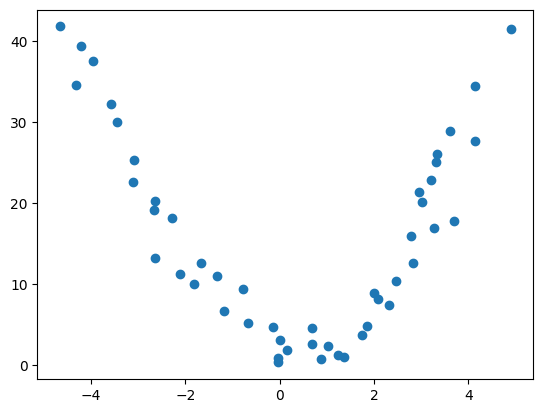

In [3]:
plt.scatter(df['Temperature (°C)'],df['Ice Cream Sales (units)'])
plt.show()

### 2 

In [4]:
df.isna().sum()

Temperature (°C)           0
Ice Cream Sales (units)    0
dtype: int64

### 3

In [5]:
y=df['Ice Cream Sales (units)']
x=df[['Temperature (°C)']]

### 4


In [6]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2,random_state=42)
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((39, 1), (10, 1), (39,), (10,))

In [7]:
from sklearn.preprocessing import PolynomialFeatures
poly=PolynomialFeatures(degree=3)


In [8]:
xtrain_poly=poly.fit_transform(x_train)
xtrain_poly[:5]

array([[  1.        ,  -2.11186969,   4.45999359,  -9.41892528],
       [  1.        ,  -3.57855372,  12.8060467 , -45.82712601],
       [  1.        ,   2.31859124,   5.37586534,  12.46443427],
       [  1.        ,  -2.67246083,   7.14204687, -19.08684049],
       [  1.        ,  -3.94966109,  15.59982272, -61.61401279]])

In [9]:
lr=LinearRegression()
lr.fit(xtrain_poly,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [10]:
m=lr.coef_
m

array([ 0.        , -1.39956426,  1.87501919,  0.05451597])

In [11]:
c=lr.intercept_
c

np.float64(2.840530985282797)

In [12]:
x1=poly.transform([[25]])
x1

C:\ProgramData\Anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


array([[1.0000e+00, 2.5000e+01, 6.2500e+02, 1.5625e+04]])

In [13]:
lr.predict(x1)

array([1991.55040278])

In [16]:
print(f"MSE = {mean_squared_error(y_test,lr.predict(poly.fit_transform(x_test)))}")
print(f"MAE = {mean_absolute_error(y_test,lr.predict(poly.fit_transform(x_test)))}")
print(f"r2 score = {r2_score(y_test,lr.predict(poly.fit_transform(x_test)))}")

MSE = 15.120009451229496
MAE = 3.22812112977689
r2 score = 0.8405107685716914
